# Full Workflow — BeH₂
## Molecule → HF → CASCI + VQE → Properties

A complete computational chemistry pipeline using **qoro-maestro-pyscf**.

This notebook walks through each step of a real quantum chemistry study on BeH₂,
a molecule with interesting multi-reference character due to the near-degeneracy
of the Be 2s and 2p orbitals.

In [18]:
import time
import numpy as np
import matplotlib.pyplot as plt
from pyscf import gto, scf, mcscf, mrpt

from qoro_maestro_pyscf import MaestroSolver
from qoro_maestro_pyscf.properties import (
    compute_dipole_moment,
    compute_natural_orbitals,
)

# Dark theme for plots
plt.style.use('dark_background')
plt.rcParams.update({
    'figure.facecolor': '#0d1117',
    'axes.facecolor': '#161b22',
    'axes.edgecolor': '#30363d',
    'text.color': '#c9d1d9',
    'axes.labelcolor': '#c9d1d9',
    'xtick.color': '#8b949e',
    'ytick.color': '#8b949e',
    'grid.color': '#21262d',
    'font.family': 'sans-serif',
})

## Step 1 — Molecule Definition

BeH₂ in a linear geometry with the STO-3G basis set.

In [19]:
mol = gto.M(
    atom="""
        Be  0.000  0.000  0.000
        H   0.000  0.000  1.334
        H   0.000  0.000 -1.334
    """,
    basis="sto-3g",
    symmetry=False,
    verbose=0,
)
print(f"Molecule: BeH₂ (STO-3G)")
print(f"Atoms: {mol.natm}, AOs: {mol.nao_nr()}")

Molecule: BeH₂ (STO-3G)
Atoms: 3, AOs: 7


## Step 2 — Hartree-Fock

Starting point: a single-determinant mean-field solution.

In [20]:
hf = scf.RHF(mol).run()
print(f"E(HF) = {hf.e_tot:+.10f} Ha")

E(HF) = -15.5598384372 Ha


## Step 3 — CASCI + VQE on Maestro

We use a (2e, 3o) active space → 6 qubits. The UCCSD ansatz captures
the static correlation that Hartree-Fock misses.

**CASCI** (not CASSCF) is used here because VQE runs once on fixed HF
orbitals, avoiding the convergence issues of CASSCF macro-iterations.

In [21]:
norb = 3   # Be 2s, 2pz + H 1s orbitals
nelec = 2
backend = "cpu"

cas = mcscf.CASCI(hf, norb, nelec)
cas.fcisolver = MaestroSolver(
    ansatz="uccsd",
    backend=backend,
    maxiter=300,
    verbose=True,
)

t0 = time.perf_counter()
casci_e = cas.kernel()[0]
casci_time = time.perf_counter() - t0

print(f"\nE(CASCI+VQE) = {casci_e:+.10f} Ha  ({casci_time:.1f}s)")

  [MaestroSolver] Backend : CPU/QCSim (statevector)
  [MaestroSolver] Qubits  : 6
  [MaestroSolver] Ansatz  : uccsd
  [MaestroSolver] Params  : 14
  [MaestroSolver] Paulis  : 33
    iter    1  |  E = -0.6756435954
    iter   20  |  E = -1.0158607076
    iter   40  |  E = -1.1433310804
    iter   60  |  E = -1.1874476065
    iter   80  |  E = -1.2395387129
    iter  100  |  E = -1.2587791397
    iter  120  |  E = -1.2665499171
    iter  140  |  E = -1.2707472151
    iter  160  |  E = -1.2727792316
    iter  180  |  E = -1.2739753864
    iter  200  |  E = -1.2746205308
    iter  220  |  E = -1.2749927599
    iter  240  |  E = -1.2753245690
    iter  260  |  E = -1.2757315257
    iter  280  |  E = -1.2759481612
    iter  300  |  E = -1.2760871599
  [MaestroSolver] Converged : False
  [MaestroSolver] E(VQE)    : -1.2760871599
  [MaestroSolver] E(total)  : -15.5597094811
  [MaestroSolver] Time      : 0.23s

E(CASCI+VQE) = -15.5597094811 Ha  (0.3s)


## Step 4 — NEVPT2 (Perturbation Theory)

NEVPT2 adds dynamic correlation on top of the CASCI solution.

> **Note:** NEVPT2 requires a 3-body reduced density matrix (3-RDM),
> which needs a CI vector in FCI format. VQE solvers produce parameterised
> circuits instead, so NEVPT2 is skipped here. This is a known limitation
> shared by all VQE-based solvers.

In [22]:
t0 = time.perf_counter()
try:
    nevpt2_corr = mrpt.NEVPT(cas).kernel()
    nevpt2_e = casci_e + nevpt2_corr
    nevpt2_time = time.perf_counter() - t0
    print(f"ΔE(NEVPT2) = {nevpt2_corr:+.10f} Ha")
    print(f"E(CASCI+NEVPT2) = {nevpt2_e:+.10f} Ha  ({nevpt2_time:.1f}s)")
except (AssertionError, RuntimeError, TypeError):
    nevpt2_e = None
    print("⚠ NEVPT2 requires a 3-RDM from the CI vector.")
    print("VQE solvers produce circuits, not CI vectors — skipping.")

  [MaestroSolver] Backend : CPU/QCSim (statevector)
  [MaestroSolver] Qubits  : 6
  [MaestroSolver] Ansatz  : uccsd
  [MaestroSolver] Params  : 14
  [MaestroSolver] Paulis  : 33
    iter    1  |  E = -0.6756435954
    iter   20  |  E = -1.0158607076
    iter   40  |  E = -1.1433310804
    iter   60  |  E = -1.1874476065
    iter   80  |  E = -1.2395387129
    iter  100  |  E = -1.2587791397
    iter  120  |  E = -1.2665499171
    iter  140  |  E = -1.2707472151
    iter  160  |  E = -1.2727792316
    iter  180  |  E = -1.2739753864
    iter  200  |  E = -1.2746205308
    iter  220  |  E = -1.2749927599
    iter  240  |  E = -1.2753245690
    iter  260  |  E = -1.2757315257
    iter  280  |  E = -1.2759481612
    iter  300  |  E = -1.2760871599
  [MaestroSolver] Converged : False
  [MaestroSolver] E(VQE)    : -1.2760871599
  [MaestroSolver] E(total)  : -15.5597094811
  [MaestroSolver] Time      : 0.18s
⚠ NEVPT2 requires a 3-RDM from the CI vector.
VQE solvers produce circuits, not CI ve

## Step 5 — Properties

Extract molecular properties from the VQE wavefunction:
- **Dipole moment** — should be ~0 for symmetric BeH₂
- **Natural orbital occupations** — show correlation effects

In [23]:
ci = cas.ci
rdm1 = cas.fcisolver.make_rdm1(ci, norb, (1, 1))

# Dipole moment
dipole, mag = compute_dipole_moment(mol, cas.mo_coeff, rdm1)
print(f"Dipole: [{dipole[0]:+.4f}, {dipole[1]:+.4f}, {dipole[2]:+.4f}] D")
print(f"|μ| = {mag:.4f} D  (should be ~0 by symmetry)")

# Natural orbital occupations
occ, _ = compute_natural_orbitals(rdm1)
print(f"Natural occupations: [{', '.join(f'{n:.4f}' for n in occ)}]")

Dipole: [+0.0000, -0.0000, +0.0000] D
|μ| = 0.0000 D  (should be ~0 by symmetry)
Natural occupations: [1.9989, 0.0022, 0.0009]


## Summary & Plots

Compare all methods against the exact FCI solution.

In [24]:
# FCI reference
cas_fci = mcscf.CASCI(hf, norb, nelec)
cas_fci.verbose = 0
fci_e = cas_fci.kernel()[0]

# Build comparison data (skip NEVPT2 if unavailable)
methods = ['HF', 'CASCI+VQE\n(Maestro)', 'FCI\n(exact)']
energies = [hf.e_tot, casci_e, fci_e]
colors = ['#f85149', '#d29922', '#58a6ff']

if nevpt2_e is not None:
    methods.insert(2, 'CASCI +\nNEVPT2')
    energies.insert(2, nevpt2_e)
    colors.insert(2, '#3fb950')

errors = [abs(e - fci_e) * 1000 for e in energies]

print(f"{'Method':<22s}  {'Energy (Ha)':>14s}  {'Δ FCI (mHa)':>12s}")
print('─' * 52)
for m, e, err in zip(methods, energies, errors):
    label = m.replace('\n', ' ')
    print(f"{label:<22s}  {e:+14.8f}  {err:10.2f}")

Method                     Energy (Ha)   Δ FCI (mHa)
────────────────────────────────────────────────────
HF                        -15.55983844        0.55
CASCI+VQE (Maestro)       -15.55970948        0.68
FCI (exact)               -15.56038754        0.00


In [ ]:
# ── Energy Comparison Plot ──
fig, ax = plt.subplots(figsize=(10, 4))

method_labels = [m.replace('\n', ' ') for m in methods]
bar_colors_plot = colors.copy()

bars = ax.barh(method_labels, errors, color=bar_colors_plot,
               edgecolor='#30363d', height=0.55)
ax.set_xlabel('Error to FCI (mHa)', fontsize=13)
ax.set_title('BeH₂ — Method Accuracy Comparison', fontsize=15,
             fontweight='bold', pad=15)
ax.invert_yaxis()

# Chemical accuracy threshold
chem_acc = 1.6
ax.axvline(x=chem_acc, color='#3fb950', linestyle='--', linewidth=1.5, alpha=0.8)
ax.text(chem_acc + 0.03, len(methods) - 0.6,
        'chemical\naccuracy', fontsize=9, color='#3fb950', va='top')

# Sensible x-axis: go a bit beyond chemical accuracy to show the threshold
ax.set_xlim(0, max(max(errors) * 1.3, chem_acc * 1.3))

# Value labels + absolute energy annotations
for i, (bar, err, e) in enumerate(zip(bars, errors, energies)):
    # Error label
    if err > 0.001:
        ax.text(bar.get_width() + 0.04, bar.get_y() + bar.get_height() / 2,
                f'{err:.2f} mHa', va='center', fontsize=11, color='#c9d1d9')
    else:
        ax.text(0.04, bar.get_y() + bar.get_height() / 2,
                'exact', va='center', fontsize=11, color='#58a6ff', fontweight='bold')

# Checkmark for methods within chemical accuracy
for i, err in enumerate(errors):
    symbol = '✓' if err < chem_acc else '✗'
    color = '#3fb950' if err < chem_acc else '#f85149'
    ax.text(-0.08, i, symbol, va='center', ha='center', fontsize=14,
            color=color, fontweight='bold',
            transform=ax.get_yaxis_transform())

plt.tight_layout()
plt.savefig('energy_ladder.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()
print('Saved: energy_ladder.png')

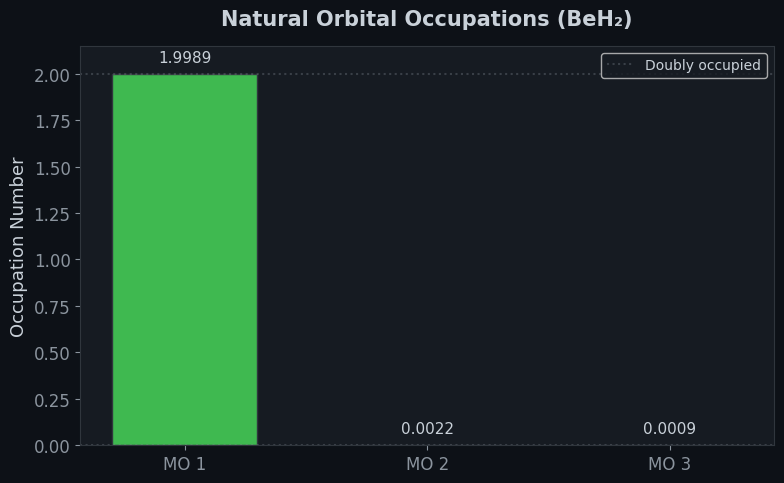

Saved: natural_occupations.png


In [26]:
# ── Natural Orbital Occupations ──
fig, ax = plt.subplots(figsize=(8, 5))

orb_labels = [f'MO {i+1}' for i in range(len(occ))]
bar_colors = ['#3fb950' if n > 0.1 else '#8b949e' for n in occ]
bars = ax.bar(orb_labels, occ, color=bar_colors, edgecolor='#30363d', width=0.6)

ax.set_ylabel('Occupation Number', fontsize=13)
ax.set_title('Natural Orbital Occupations (BeH₂)', fontsize=15,
             fontweight='bold', pad=15)
ax.set_ylim(0, 2.15)
ax.axhline(y=2.0, color='#8b949e', linestyle=':', alpha=0.3, label='Doubly occupied')
ax.axhline(y=0.0, color='#8b949e', linestyle=':', alpha=0.3)

for bar, n in zip(bars, occ):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.05,
            f'{n:.4f}', ha='center', va='bottom', fontsize=11, color='#c9d1d9')

ax.legend(fontsize=10, loc='upper right')
plt.tight_layout()
plt.savefig('natural_occupations.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()
print('Saved: natural_occupations.png')